# 時間序列分析基礎 - 機器學習面試準備

本筆記本涵蓋機器學習面試的必備概念：
- 時間序列基礎與組成成分
- 定態性（Stationarity）與轉換技術
- ARIMA 與 SARIMA 建模
- 使用航空乘客資料集進行實作練習
- 面試練習題

---
# 第一部分：理論
---

## 1.1 什麼是時間序列資料？

### 定義

**時間序列**是在連續且等距的時間點上收集的一系列資料點。

### 時間序列 vs 橫斷面資料

| 面向 | 時間序列 | 橫斷面 |
|--------|-------------|----------------|
| **結構** | 隨時間的觀測值 | 單一時間點的觀測值 |
| **順序** | 順序重要（時間相依性） | 順序不重要 |
| **獨立性** | 通常**不**獨立 | 通常假設獨立 |
| **範例** | 股價、溫度、銷售額 | 問卷調查、病患資料 |

### 主要特徵

1. **時間順序性**：觀測值的順序具有意義
2. **自相關（Autocorrelation）**：過去的值會影響未來的值
3. **模式**：可能呈現趨勢（trend）、季節性（seasonality）或週期（cycles）

## 1.2 時間序列的組成成分

時間序列 $Y_t$ 可以分解為：

### 1. 趨勢（Trend，$T_t$）
- 資料長期的上升或下降
- 範例：人口成長、科技採用率

### 2. 季節性（Seasonality，$S_t$）
- 以固定間隔重複出現的規律、可預測模式
- 範例：節日銷售、夏季氣溫

### 3. 殘差/雜訊（Residual/Noise，$R_t$）
- 無法被趨勢或季節性解釋的隨機波動
- 若模型設定良好，殘差應為定態

### 分解模型

| 模型 | 公式 | 使用時機 |
|-------|---------|-------------|
| **加法模型** | $Y_t = T_t + S_t + R_t$ | 季節變異隨時間保持恆定 |
| **乘法模型** | $Y_t = T_t \times S_t \times R_t$ | 季節變異隨序列水準成長 |

## 1.3 定態性（Stationarity）

### 為什麼定態性很重要

大多數時間序列模型（ARIMA、ARMA）假設資料是**定態**的。非定態資料必須在建模前進行轉換。

### 定義

若時間序列的統計性質不隨時間改變，則該序列為**定態**：

| 性質 | 定態 | 非定態 |
|----------|------------|----------------|
| 平均數 | 恆定 | 隨時間改變 |
| 變異數 | 恆定 | 隨時間改變 |
| 自相關 | 僅取決於落後期 | 取決於時間 |

### 非定態的類型

1. **趨勢**：平均數隨時間改變
2. **季節性**：週期性波動
3. **異質變異數（Heteroscedasticity）**：變異數隨時間改變

### 檢驗定態性

**1. 視覺檢驗**
- 繪製序列圖：觀察趨勢、變異數變化
- 檢查滾動平均數與標準差

**2. 擴增 Dickey-Fuller（ADF）檢定**
- $H_0$：序列具有單位根（非定態）
- $H_1$：序列為定態
- 若 p-value < 0.05，拒絕 $H_0$ → 序列為定態

### 使資料變成定態的方法

| 技術 | 處理問題 | 方法 |
|-----------|-----------|--------|
| **差分** | 趨勢 | $Y'_t = Y_t - Y_{t-1}$ |
| **季節差分** | 季節性 | $Y'_t = Y_t - Y_{t-s}$ |
| **對數轉換** | 異質變異數 | $Y'_t = \log(Y_t)$ |

## 1.4 ACF 與 PACF

### 自相關函數（Autocorrelation Function，ACF）

測量時間序列與其落後版本之間的相關性。

$$\text{ACF}(k) = \text{Corr}(Y_t, Y_{t-k})$$

- 包含直接與間接相關
- 用於識別 MA 階數（q）

### 偏自相關函數（Partial Autocorrelation Function，PACF）

測量 $Y_t$ 與 $Y_{t-k}$ 在移除中間落後期影響後的相關性。

- 分離出每個落後期的直接關係
- 用於識別 AR 階數（p）

### 使用 ACF/PACF 選擇 ARIMA 參數

| 模式 | ACF | PACF | 模型 |
|---------|-----|------|-------|
| AR(p) | 拖尾（逐漸衰減） | 在落後 p 期後截斷 | 用 PACF 找 p |
| MA(q) | 在落後 q 期後截斷 | 拖尾 | 用 ACF 找 q |
| ARMA(p,q) | 拖尾 | 拖尾 | 嘗試不同組合 |

**「截斷」** = 急遽下降至接近零

**「拖尾」** = 逐漸衰減趨近零

## 1.5 ARIMA 模型

### 組成成分：ARIMA(p, d, q)

| 參數 | 名稱 | 意義 |
|-----------|------|--------|
| **p** | AR 階數 | 自迴歸項的數量（Y 的落後期） |
| **d** | 差分 | 資料差分的次數 |
| **q** | MA 階數 | 移動平均項的數量（誤差的落後期） |

### 數學公式

**AR(p)（自迴歸）**：$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + ... + \phi_p Y_{t-p} + \epsilon_t$

**MA(q)（移動平均）**：$Y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + ... + \theta_q \epsilon_{t-q}$

**ARIMA(p,d,q)**：在差分後的資料上結合 AR 與 MA

### 特殊情況

| 模型 | 參數 | 描述 |
|-------|------------|-------------|
| ARIMA(0,0,0) | 白噪音 | 隨機波動 |
| ARIMA(1,0,0) | AR(1) | 一階自迴歸 |
| ARIMA(0,0,1) | MA(1) | 一階移動平均 |
| ARIMA(0,1,0) | 隨機漫步 | 非定態，差分後為白噪音 |

## 1.6 處理季節性資料的 SARIMA

### SARIMA(p, d, q)(P, D, Q, s)

擴展 ARIMA 以處理季節性，加入額外參數：

| 參數 | 意義 |
|-----------|--------|
| P | 季節 AR 階數 |
| D | 季節差分 |
| Q | 季節 MA 階數 |
| s | 季節週期（例如：月資料具有年度季節性則 s=12） |

### 範例

SARIMA(1, 1, 1)(1, 1, 1, 12) 用於月資料：
- 非季節部分：AR(1)、差分(1)、MA(1)
- 季節部分：AR(1)、差分(1)、MA(1)，週期為 12

---
# 第二部分：實作
---

## 2.1 環境設定與資料載入

In [6]:
# 核心套件
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# 時間序列專用套件
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 評估指標
from sklearn.metrics import mean_squared_error, mean_absolute_error
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Heiti TC', 'Arial Unicode MS']

# 設定
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("環境設定完成！")

環境設定完成！


In [3]:
def load_air_passengers(data_dir: Path = Path('data')) -> pd.Series:
    """
    載入航空乘客資料集。
    若本機不存在則從 GitHub 下載。
    """
    data_dir.mkdir(exist_ok=True)
    filepath = data_dir / 'air_passengers.csv'
    
    if not filepath.exists():
        print("正在下載航空乘客資料集...")
        url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
        df = pd.read_csv(url)
        df.to_csv(filepath, index=False)
        print(f"資料集已儲存至 {filepath}")
    else:
        print(f"從 {filepath} 載入資料集")
        df = pd.read_csv(filepath)
    
    # 轉換為正確的時間序列格式
    df['Month'] = pd.to_datetime(df['Month'])
    df.set_index('Month', inplace=True)
    
    # 回傳 Series
    series = df['Passengers']
    series.index.freq = 'MS'  # 月初頻率
    
    return series

# 載入資料
passengers = load_air_passengers()
print(f"\n資料集形狀：{passengers.shape}")
print(f"日期範圍：{passengers.index.min()} 至 {passengers.index.max()}")
passengers.head(10)

正在下載航空乘客資料集...
資料集已儲存至 data/air_passengers.csv

資料集形狀：(144,)
日期範圍：1949-01-01 00:00:00 至 1960-12-01 00:00:00


Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
Freq: MS, Name: Passengers, dtype: int64

## 2.2 探索性資料分析（EDA）

In [4]:
# 基本統計量
print("=" * 50)
print("資料集統計摘要")
print("=" * 50)
print(passengers.describe())
print(f"\n遺漏值數量：{passengers.isnull().sum()}")

資料集統計摘要
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: Passengers, dtype: float64

遺漏值數量：0


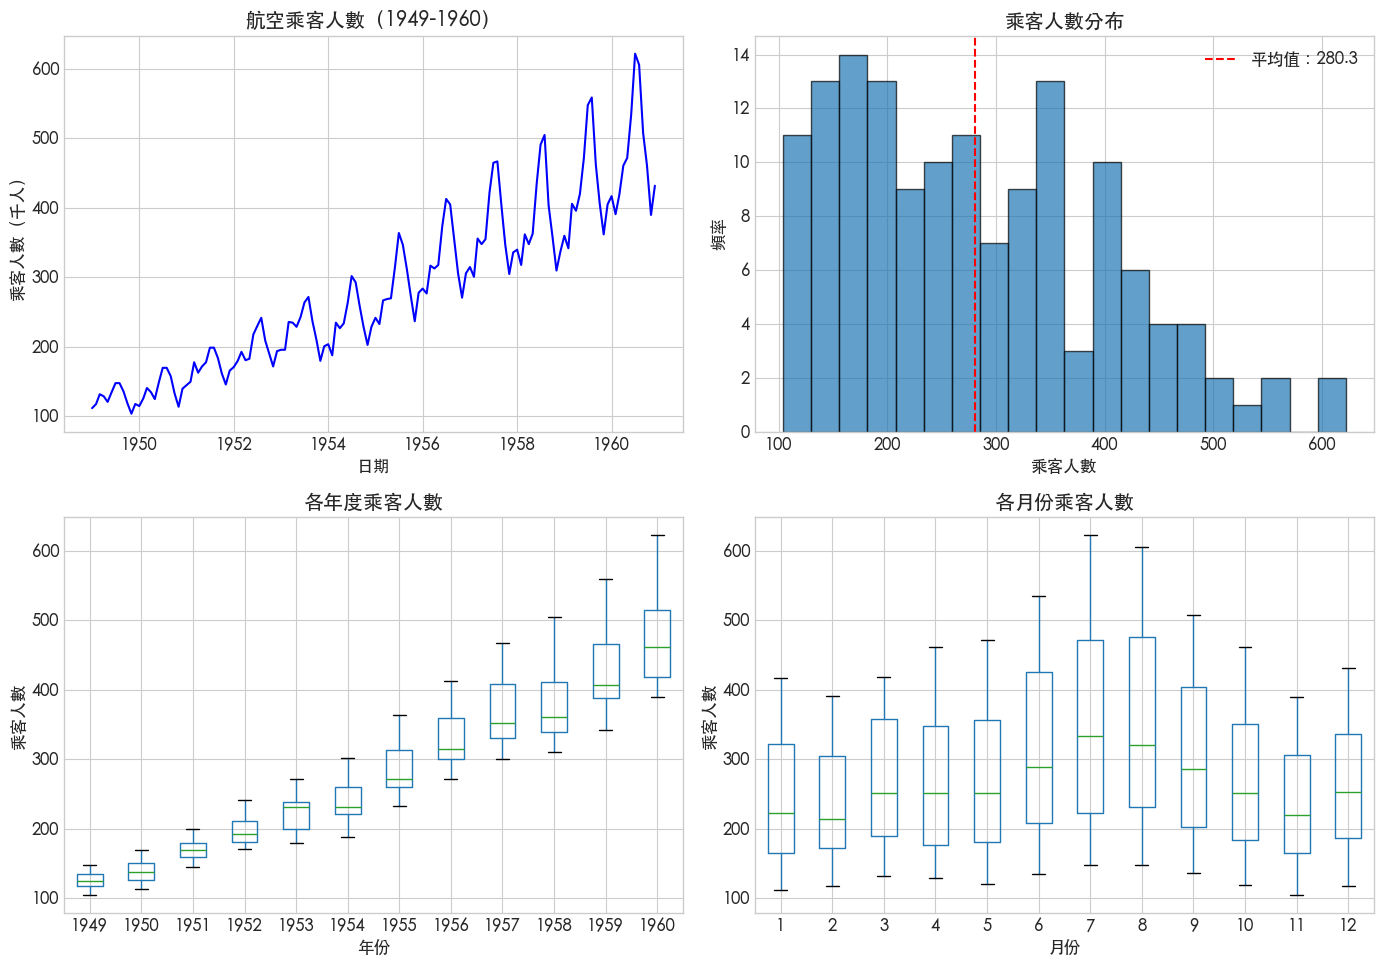

In [8]:
# 繪製時間序列圖
plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Heiti TC', 'Arial Unicode MS']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 原始序列
axes[0, 0].plot(passengers, color='blue', linewidth=1.5)
axes[0, 0].set_title('航空乘客人數（1949-1960）')
axes[0, 0].set_xlabel('日期')
axes[0, 0].set_ylabel('乘客人數（千人）')

# 分布圖
axes[0, 1].hist(passengers, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(passengers.mean(), color='red', linestyle='--', label=f'平均值：{passengers.mean():.1f}')
axes[0, 1].set_title('乘客人數分布')
axes[0, 1].set_xlabel('乘客人數')
axes[0, 1].set_ylabel('頻率')
axes[0, 1].legend()

# 按年份的盒鬚圖
passengers_df = passengers.to_frame()
passengers_df['Year'] = passengers_df.index.year
passengers_df.boxplot(column='Passengers', by='Year', ax=axes[1, 0])
axes[1, 0].set_title('各年度乘客人數')
axes[1, 0].set_xlabel('年份')
axes[1, 0].set_ylabel('乘客人數')
plt.suptitle('')  # 移除自動標題

# 按月份的盒鬚圖
passengers_df['Month_Num'] = passengers_df.index.month
passengers_df.boxplot(column='Passengers', by='Month_Num', ax=axes[1, 1])
axes[1, 1].set_title('各月份乘客人數')
axes[1, 1].set_xlabel('月份')
axes[1, 1].set_ylabel('乘客人數')
plt.suptitle('')  # 移除自動標題

plt.tight_layout()
plt.show()

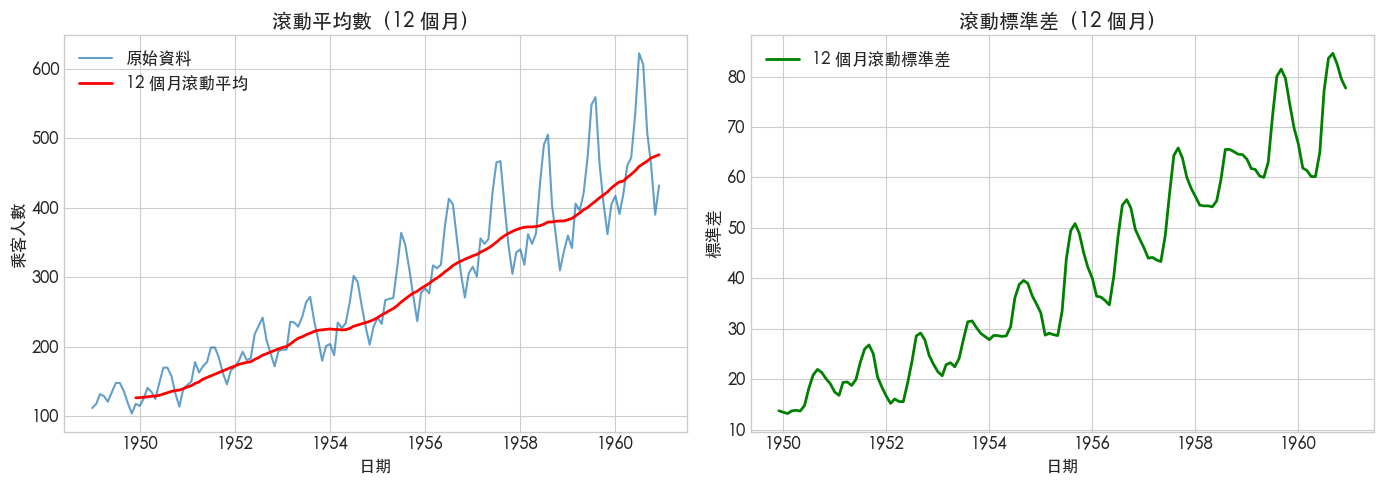

觀察結果：
- 滾動平均數顯示上升趨勢
- 滾動標準差隨時間增加（異質變異數）
- 這表示乘法分解可能更適合此資料


In [9]:
# 滾動統計量以視覺化趨勢
rolling_mean = passengers.rolling(window=12).mean()
rolling_std = passengers.rolling(window=12).std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 滾動平均數
axes[0].plot(passengers, label='原始資料', alpha=0.7)
axes[0].plot(rolling_mean, label='12 個月滾動平均', color='red', linewidth=2)
axes[0].set_title('滾動平均數（12 個月）')
axes[0].set_xlabel('日期')
axes[0].set_ylabel('乘客人數')
axes[0].legend()

# 滾動標準差
axes[1].plot(rolling_std, label='12 個月滾動標準差', color='green', linewidth=2)
axes[1].set_title('滾動標準差（12 個月）')
axes[1].set_xlabel('日期')
axes[1].set_ylabel('標準差')
axes[1].legend()

plt.tight_layout()
plt.show()

print("觀察結果：")
print("- 滾動平均數顯示上升趨勢")
print("- 滾動標準差隨時間增加（異質變異數）")
print("- 這表示乘法分解可能更適合此資料")

## 2.3 時間序列分解

In [14]:
dir(decomposition_add)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_observed',
 '_resid',
 '_seasonal',
 '_trend',
 '_weights',
 'nobs',
 'observed',
 'plot',
 'resid',
 'seasonal',
 'trend',
 'weights']

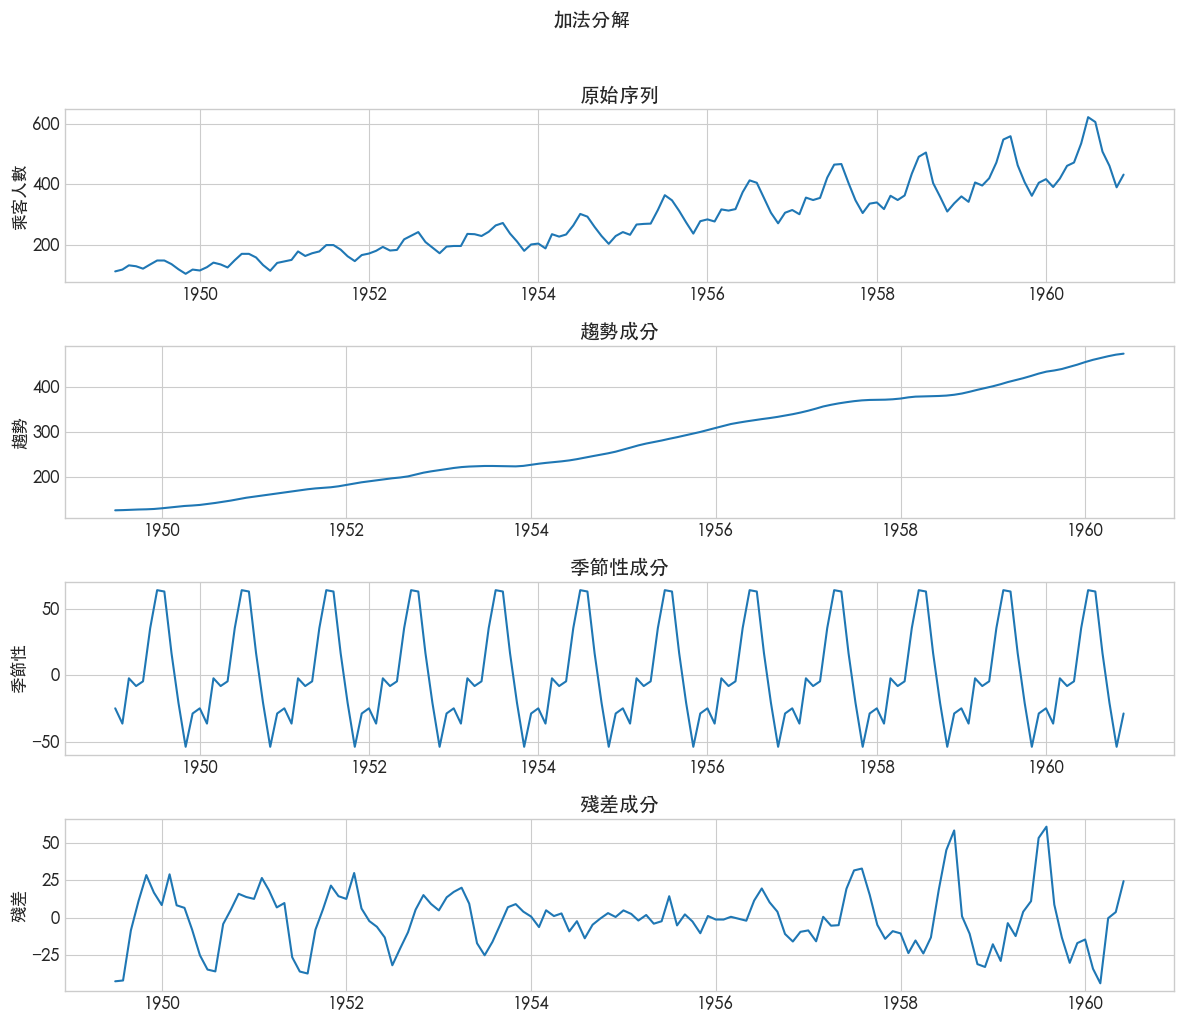

In [12]:
# 加法分解
decomposition_add = seasonal_decompose(passengers, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(passengers)
axes[0].set_title('原始序列')
axes[0].set_ylabel('乘客人數')

axes[1].plot(decomposition_add.trend)
axes[1].set_title('趨勢成分')
axes[1].set_ylabel('趨勢')

axes[2].plot(decomposition_add.seasonal)
axes[2].set_title('季節性成分')
axes[2].set_ylabel('季節性')

axes[3].plot(decomposition_add.resid)
axes[3].set_title('殘差成分')
axes[3].set_ylabel('殘差')

fig.suptitle('加法分解', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

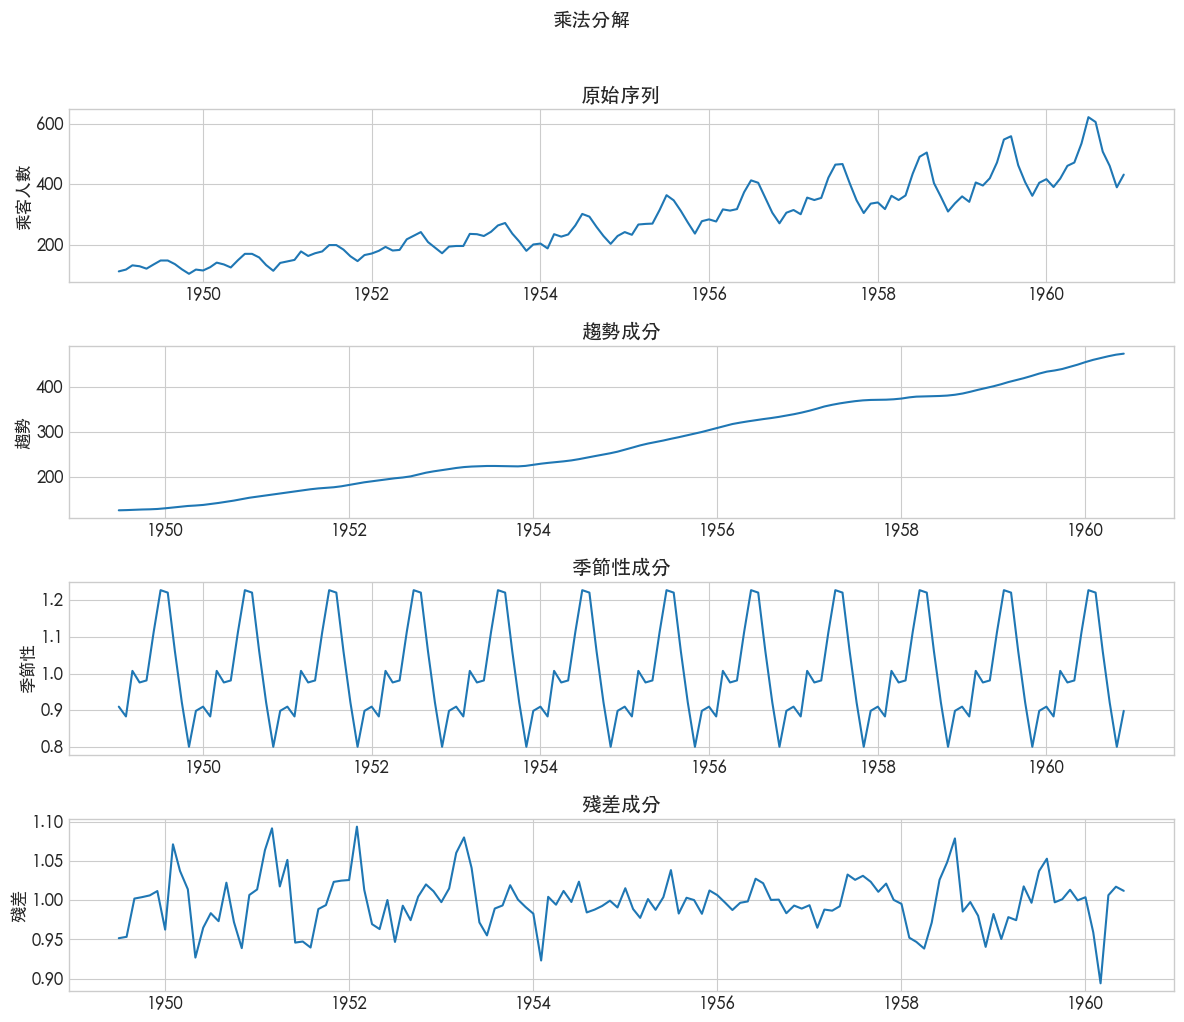

注意：乘法分解在此更為適合，因為：
- 季節變異隨序列水準增加
- 殘差呈現較恆定的變異數（同質變異數）


In [15]:
# 乘法分解（更適合此資料）
decomposition_mult = seasonal_decompose(passengers, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

axes[0].plot(passengers)
axes[0].set_title('原始序列')
axes[0].set_ylabel('乘客人數')

axes[1].plot(decomposition_mult.trend)
axes[1].set_title('趨勢成分')
axes[1].set_ylabel('趨勢')

axes[2].plot(decomposition_mult.seasonal)
axes[2].set_title('季節性成分')
axes[2].set_ylabel('季節性')

axes[3].plot(decomposition_mult.resid)
axes[3].set_title('殘差成分')
axes[3].set_ylabel('殘差')

fig.suptitle('乘法分解', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("注意：乘法分解在此更為適合，因為：")
print("- 季節變異隨序列水準增加")
print("- 殘差呈現較恆定的變異數（同質變異數）")

## 2.4 定態性檢驗與轉換

In [16]:
def adf_test(series, title=''):
    """
    執行擴增 Dickey-Fuller 檢定並印出結果。
    """
    result = adfuller(series.dropna())
    
    print(f"ADF 檢定結果：{title}")
    print("-" * 50)
    print(f"ADF 統計量：{result[0]:.4f}")
    print(f"p 值：{result[1]:.4f}")
    print(f"使用的落後期：{result[2]}")
    print(f"觀測值數量：{result[3]}")
    print("臨界值：")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    
    if result[1] < 0.05:
        print("\n結論：定態（拒絕 H0）")
        return True
    else:
        print("\n結論：非定態（無法拒絕 H0）")
        return False

In [17]:
# 檢驗原始序列
print("=" * 60)
is_stationary = adf_test(passengers, '原始序列')
print("=" * 60)

ADF 檢定結果：原始序列
--------------------------------------------------
ADF 統計量：0.8154
p 值：0.9919
使用的落後期：13
觀測值數量：130
臨界值：
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788

結論：非定態（無法拒絕 H0）


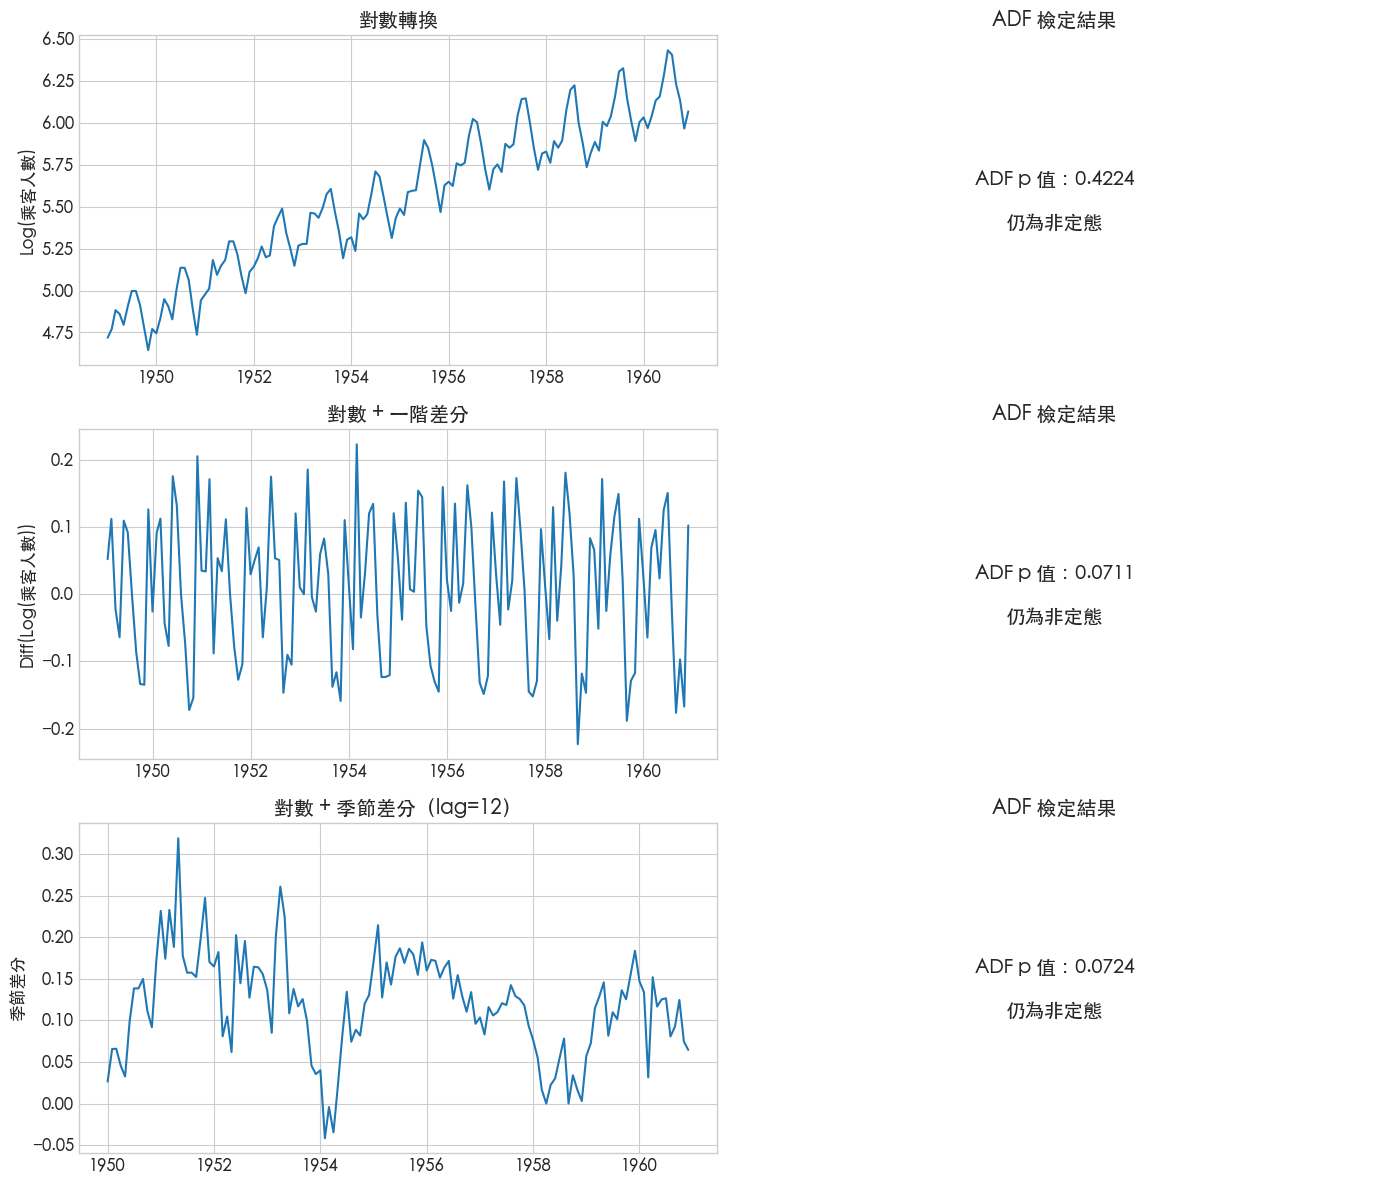

In [18]:
# 套用轉換以達成定態性
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# 1. 對數轉換（穩定變異數）
passengers_log = np.log(passengers)
axes[0, 0].plot(passengers_log)
axes[0, 0].set_title('對數轉換')
axes[0, 0].set_ylabel('Log(乘客人數)')

# ADF 檢定
axes[0, 1].text(0.5, 0.5, f"ADF p 值：{adfuller(passengers_log)[1]:.4f}\n\n仍為非定態", 
                ha='center', va='center', fontsize=14, transform=axes[0, 1].transAxes)
axes[0, 1].set_title('ADF 檢定結果')
axes[0, 1].axis('off')

# 2. 一階差分（移除趨勢）
passengers_diff = passengers_log.diff().dropna()
axes[1, 0].plot(passengers_diff)
axes[1, 0].set_title('對數 + 一階差分')
axes[1, 0].set_ylabel('Diff(Log(乘客人數))')

# ADF 檢定
adf_result = adfuller(passengers_diff)
axes[1, 1].text(0.5, 0.5, f"ADF p 值：{adf_result[1]:.4f}\n\n{'定態！' if adf_result[1] < 0.05 else '仍為非定態'}", 
                ha='center', va='center', fontsize=14, transform=axes[1, 1].transAxes)
axes[1, 1].set_title('ADF 檢定結果')
axes[1, 1].axis('off')

# 3. 季節差分（移除季節性）
passengers_seasonal_diff = passengers_log.diff(12).dropna()
axes[2, 0].plot(passengers_seasonal_diff)
axes[2, 0].set_title('對數 + 季節差分（lag=12）')
axes[2, 0].set_ylabel('季節差分')

# ADF 檢定
adf_result_seasonal = adfuller(passengers_seasonal_diff)
axes[2, 1].text(0.5, 0.5, f"ADF p 值：{adf_result_seasonal[1]:.4f}\n\n{'定態！' if adf_result_seasonal[1] < 0.05 else '仍為非定態'}", 
                ha='center', va='center', fontsize=14, transform=axes[2, 1].transAxes)
axes[2, 1].set_title('ADF 檢定結果')
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

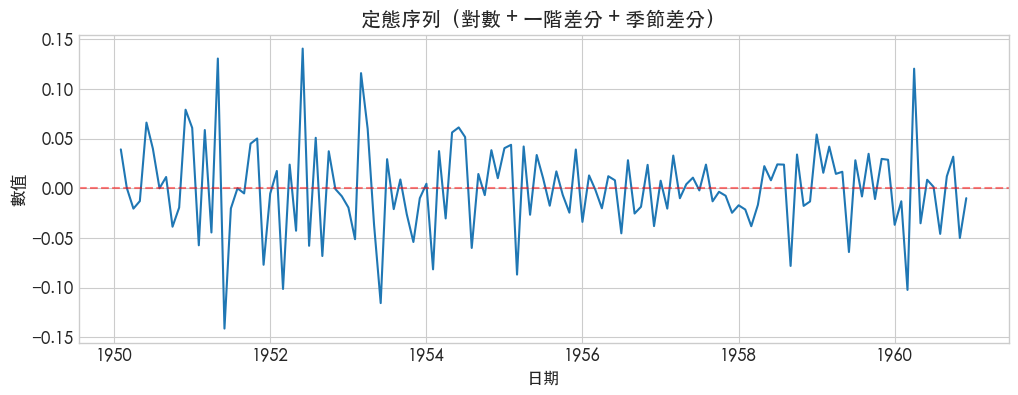

ADF 檢定結果：完全轉換後的序列
--------------------------------------------------
ADF 統計量：-4.4433
p 值：0.0002
使用的落後期：12
觀測值數量：118
臨界值：
   1%: -3.4870
   5%: -2.8864
   10%: -2.5800

結論：定態（拒絕 H0）


In [19]:
# 最終轉換：對數 + 一階差分 + 季節差分
passengers_stationary = passengers_log.diff().diff(12).dropna()

plt.figure(figsize=(12, 4))
plt.plot(passengers_stationary)
plt.title('定態序列（對數 + 一階差分 + 季節差分）')
plt.xlabel('日期')
plt.ylabel('數值')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

print("=" * 60)
adf_test(passengers_stationary, '完全轉換後的序列')
print("=" * 60)

## 2.5 ACF 與 PACF 分析

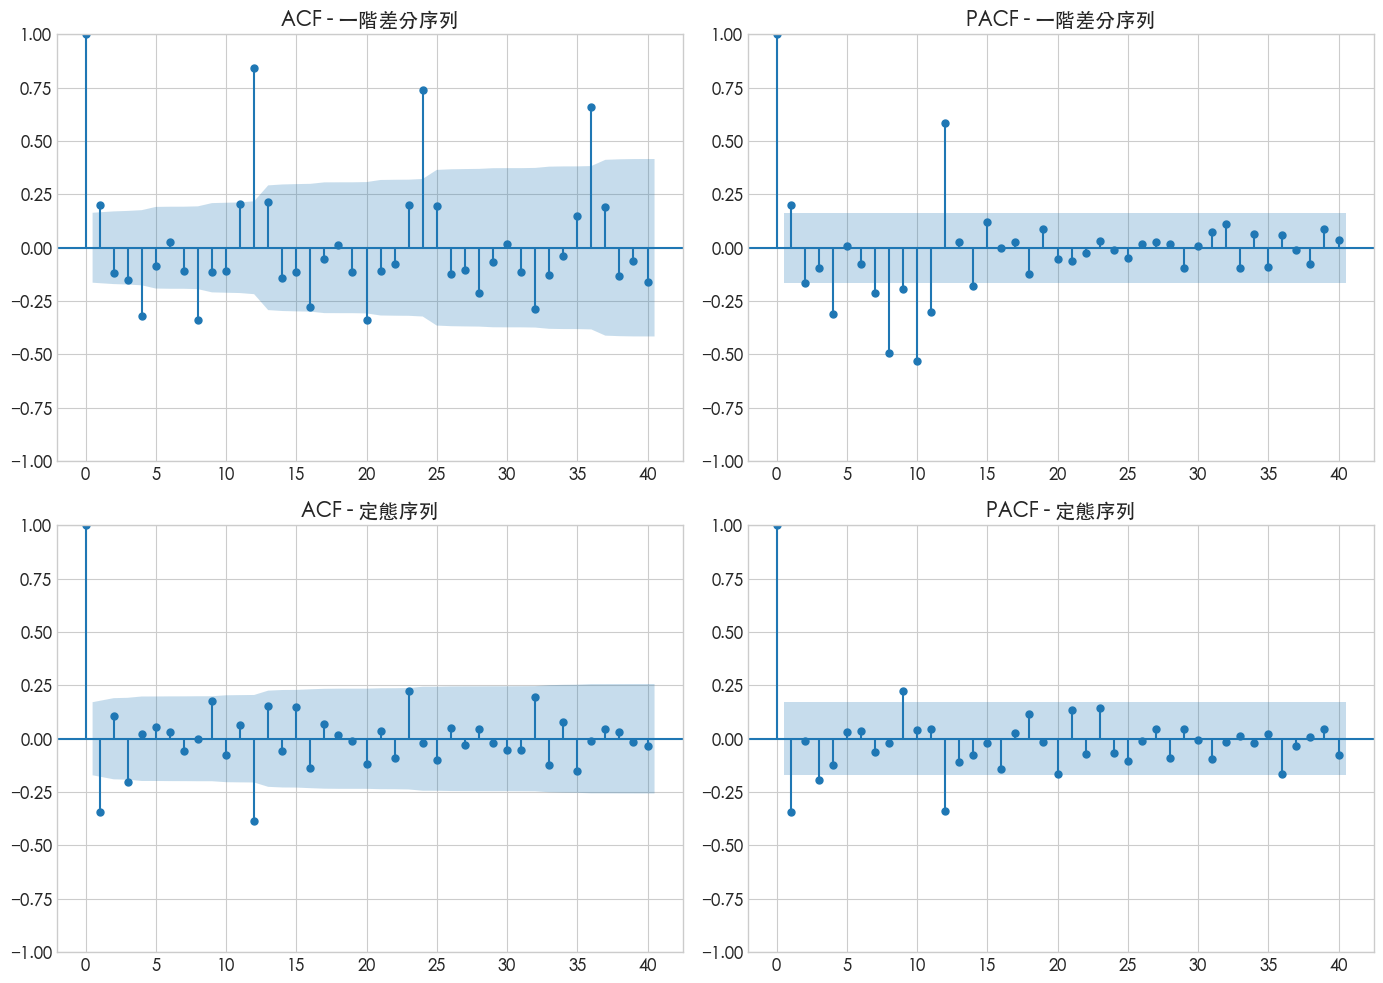

ACF/PACF 解讀：
--------------------------------------------------
- 在落後 12 期有顯著尖峰，表示存在季節性
- PACF 在落後 1 期後截斷 -> 建議 AR(1)
- ACF 呈現逐漸衰減 -> 支持 AR 成分

建議起始點：SARIMA(1,1,1)(1,1,1,12)


In [20]:
# 用於參數選擇的 ACF 與 PACF 圖
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 一階差分序列（用於非季節參數）
plot_acf(passengers_diff, ax=axes[0, 0], lags=40, alpha=0.05)
axes[0, 0].set_title('ACF - 一階差分序列')

plot_pacf(passengers_diff, ax=axes[0, 1], lags=40, alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF - 一階差分序列')

# 完全差分序列（定態）
plot_acf(passengers_stationary, ax=axes[1, 0], lags=40, alpha=0.05)
axes[1, 0].set_title('ACF - 定態序列')

plot_pacf(passengers_stationary, ax=axes[1, 1], lags=40, alpha=0.05, method='ywm')
axes[1, 1].set_title('PACF - 定態序列')

plt.tight_layout()
plt.show()

print("ACF/PACF 解讀：")
print("-" * 50)
print("- 在落後 12 期有顯著尖峰，表示存在季節性")
print("- PACF 在落後 1 期後截斷 -> 建議 AR(1)")
print("- ACF 呈現逐漸衰減 -> 支持 AR 成分")
print("\n建議起始點：SARIMA(1,1,1)(1,1,1,12)")

## 2.6 簡單預測方法

In [21]:
# 訓練/測試分割（時間序列方式 - 最後 24 個月作為測試）
train_size = len(passengers) - 24
train = passengers[:train_size]
test = passengers[train_size:]

print(f"訓練集：{train.index.min()} 至 {train.index.max()}（{len(train)} 筆觀測值）")
print(f"測試集：{test.index.min()} 至 {test.index.max()}（{len(test)} 筆觀測值）")

訓練集：1949-01-01 00:00:00 至 1958-12-01 00:00:00（120 筆觀測值）
測試集：1959-01-01 00:00:00 至 1960-12-01 00:00:00（24 筆觀測值）


In [22]:
def evaluate_forecast(y_true, y_pred, model_name="Model"):
    """
    計算並回傳預測評估指標。
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        '模型': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    }

In [23]:
# 1. 簡單移動平均
def moving_average_forecast(train, test, window=12):
    """
    使用簡單移動平均進行預測。
    """
    # 使用訓練集最後 'window' 個觀測值進行預測
    forecast = [train[-window:].mean()] * len(test)
    return pd.Series(forecast, index=test.index)

ma_forecast = moving_average_forecast(train, test, window=12)
ma_metrics = evaluate_forecast(test, ma_forecast, "簡單移動平均")

print("簡單移動平均結果：")
print("-" * 40)
for key, value in ma_metrics.items():
    if key != '模型':
        print(f"{key}: {value:.2f}")

簡單移動平均結果：
----------------------------------------
RMSE: 103.21
MAE: 77.83
MAPE (%): 15.47


In [24]:
# 2. 指數平滑法（Holt-Winters）
hw_model = ExponentialSmoothing(
    train,
    seasonal_periods=12,
    trend='add',
    seasonal='mul'  # 乘法季節性
).fit()

hw_forecast = hw_model.forecast(len(test))
hw_metrics = evaluate_forecast(test, hw_forecast, "Holt-Winters")

print("Holt-Winters 指數平滑法結果：")
print("-" * 40)
for key, value in hw_metrics.items():
    if key != '模型':
        print(f"{key}: {value:.2f}")

Holt-Winters 指數平滑法結果：
----------------------------------------
RMSE: 32.49
MAE: 28.98
MAPE (%): 6.39


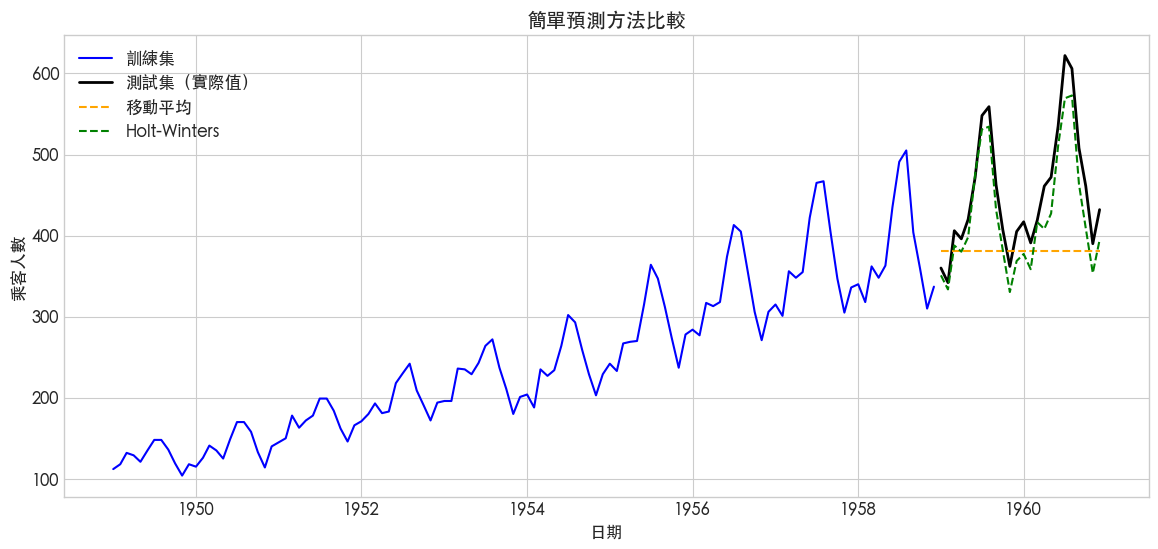

In [25]:
# 視覺化簡單預測方法
plt.figure(figsize=(14, 6))
plt.plot(train, label='訓練集', color='blue')
plt.plot(test, label='測試集（實際值）', color='black', linewidth=2)
plt.plot(ma_forecast, label='移動平均', color='orange', linestyle='--')
plt.plot(hw_forecast, label='Holt-Winters', color='green', linestyle='--')
plt.title('簡單預測方法比較')
plt.xlabel('日期')
plt.ylabel('乘客人數')
plt.legend()
plt.show()

## 2.7 ARIMA 建模

In [29]:
# 擬合 ARIMA 模型（非季節性）
# 根據 ACF/PACF 分析：p=1, d=1, q=1

arima_model = ARIMA(train, order=(1, 1, 1)).fit()

print("ARIMA(1,1,1) 模型摘要")
print("=" * 50)
print(arima_model.summary().tables[1])

ARIMA(1,1,1) 模型摘要
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5120      0.148     -3.469      0.001      -0.801      -0.223
ma.L1          0.8746      0.097      8.977      0.000       0.684       1.066
sigma2       709.3300     83.383      8.507      0.000     545.903     872.757


In [30]:
# ARIMA 預測
arima_forecast = arima_model.forecast(steps=len(test))
arima_metrics = evaluate_forecast(test, arima_forecast, "ARIMA(1,1,1)")

print("ARIMA(1,1,1) 結果：")
print("-" * 40)
for key, value in arima_metrics.items():
    if key != '模型':
        print(f"{key}: {value:.2f}")

print("\n注意：ARIMA 無法捕捉季節性，因此表現有限")

ARIMA(1,1,1) 結果：
----------------------------------------
RMSE: 118.64
MAE: 93.90
MAPE (%): 18.84

注意：ARIMA 無法捕捉季節性，因此表現有限


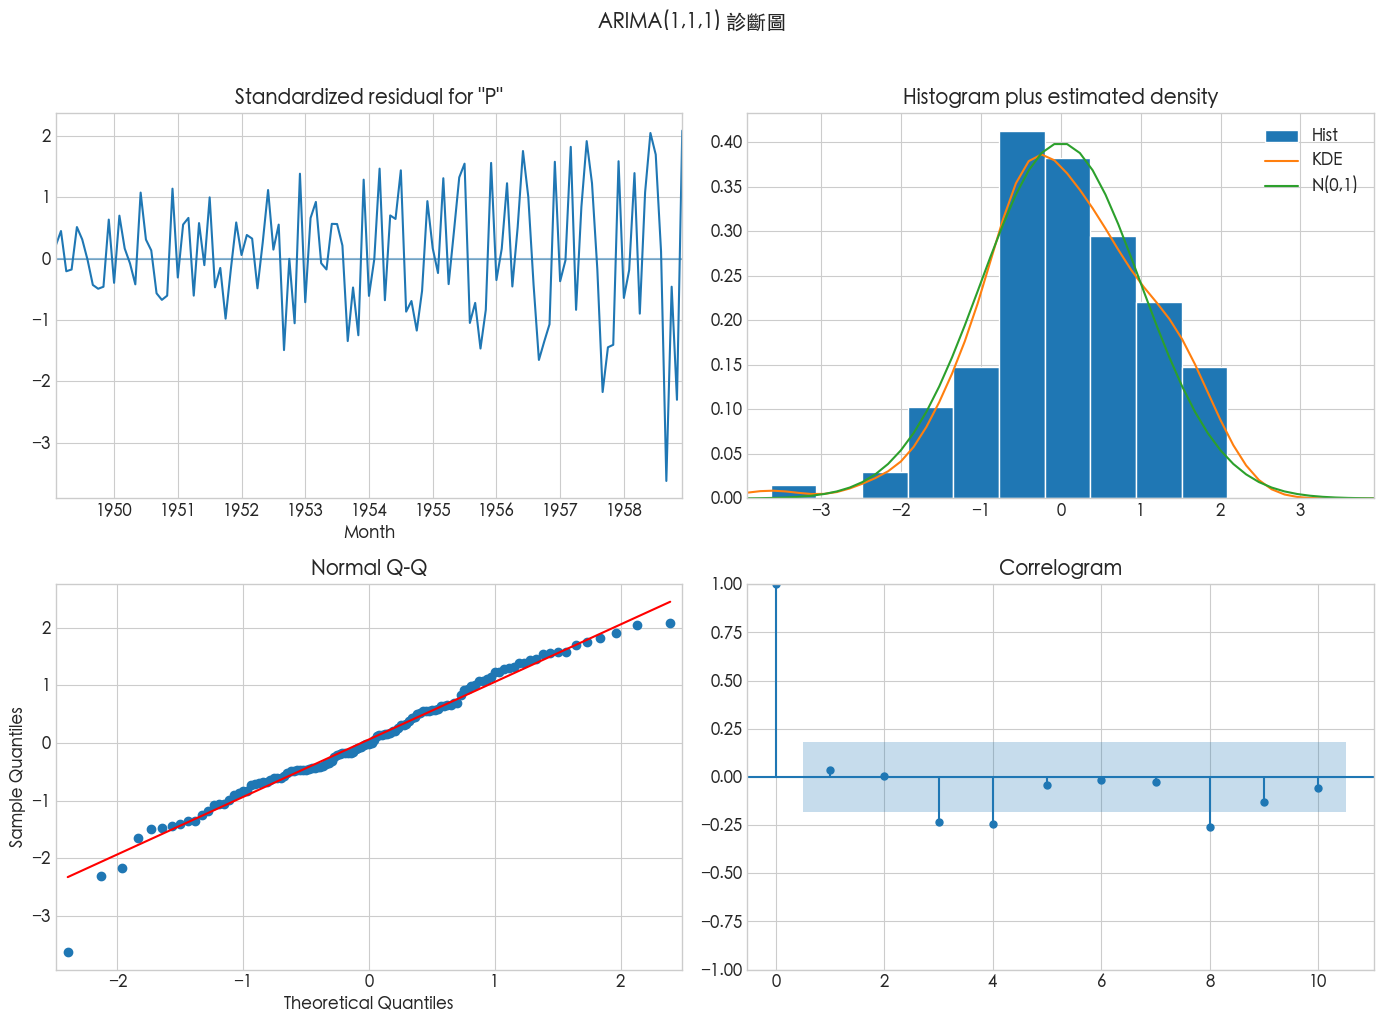

診斷解讀：
--------------------------------------------------
- 標準化殘差：應看起來像白噪音
- 直方圖：應近似常態分布
- 常態 Q-Q 圖：點應沿對角線分布
- 相關圖：殘差不應有顯著自相關


In [28]:
# 模型診斷
fig = arima_model.plot_diagnostics(figsize=(14, 10))
plt.suptitle('ARIMA(1,1,1) 診斷圖', y=1.02)
plt.tight_layout()
plt.show()

print("診斷解讀：")
print("-" * 50)
print("- 標準化殘差：應看起來像白噪音")
print("- 直方圖：應近似常態分布")
print("- 常態 Q-Q 圖：點應沿對角線分布")
print("- 相關圖：殘差不應有顯著自相關")

## 2.8 SARIMA 建模

In [31]:
# 擬合 SARIMA 模型
# SARIMA(p,d,q)(P,D,Q,s)
# 根據分析：(1,1,1)(1,1,1,12)

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("SARIMA(1,1,1)(1,1,1,12) 模型摘要")
print("=" * 60)
print(sarima_model.summary().tables[1])

SARIMA(1,1,1)(1,1,1,12) 模型摘要
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4557      0.436     -1.044      0.296      -1.311       0.400
ma.L1          0.2194      0.458      0.479      0.632      -0.677       1.116
ar.S.L12      -0.6185      0.157     -3.943      0.000      -0.926      -0.311
ma.S.L12       0.6321      0.276      2.294      0.022       0.092       1.172
sigma2       100.0779     17.727      5.646      0.000      65.334     134.822


In [32]:
# SARIMA 預測
sarima_forecast = sarima_model.forecast(steps=len(test))
sarima_metrics = evaluate_forecast(test, sarima_forecast, "SARIMA(1,1,1)(1,1,1,12)")

print("SARIMA(1,1,1)(1,1,1,12) 結果：")
print("-" * 40)
for key, value in sarima_metrics.items():
    if key != '模型':
        print(f"{key}: {value:.2f}")

print("\nSARIMA 能捕捉季節性，顯著提升預測表現！")

SARIMA(1,1,1)(1,1,1,12) 結果：
----------------------------------------
RMSE: 75.63
MAE: 69.90
MAPE (%): 15.22

SARIMA 能捕捉季節性，顯著提升預測表現！


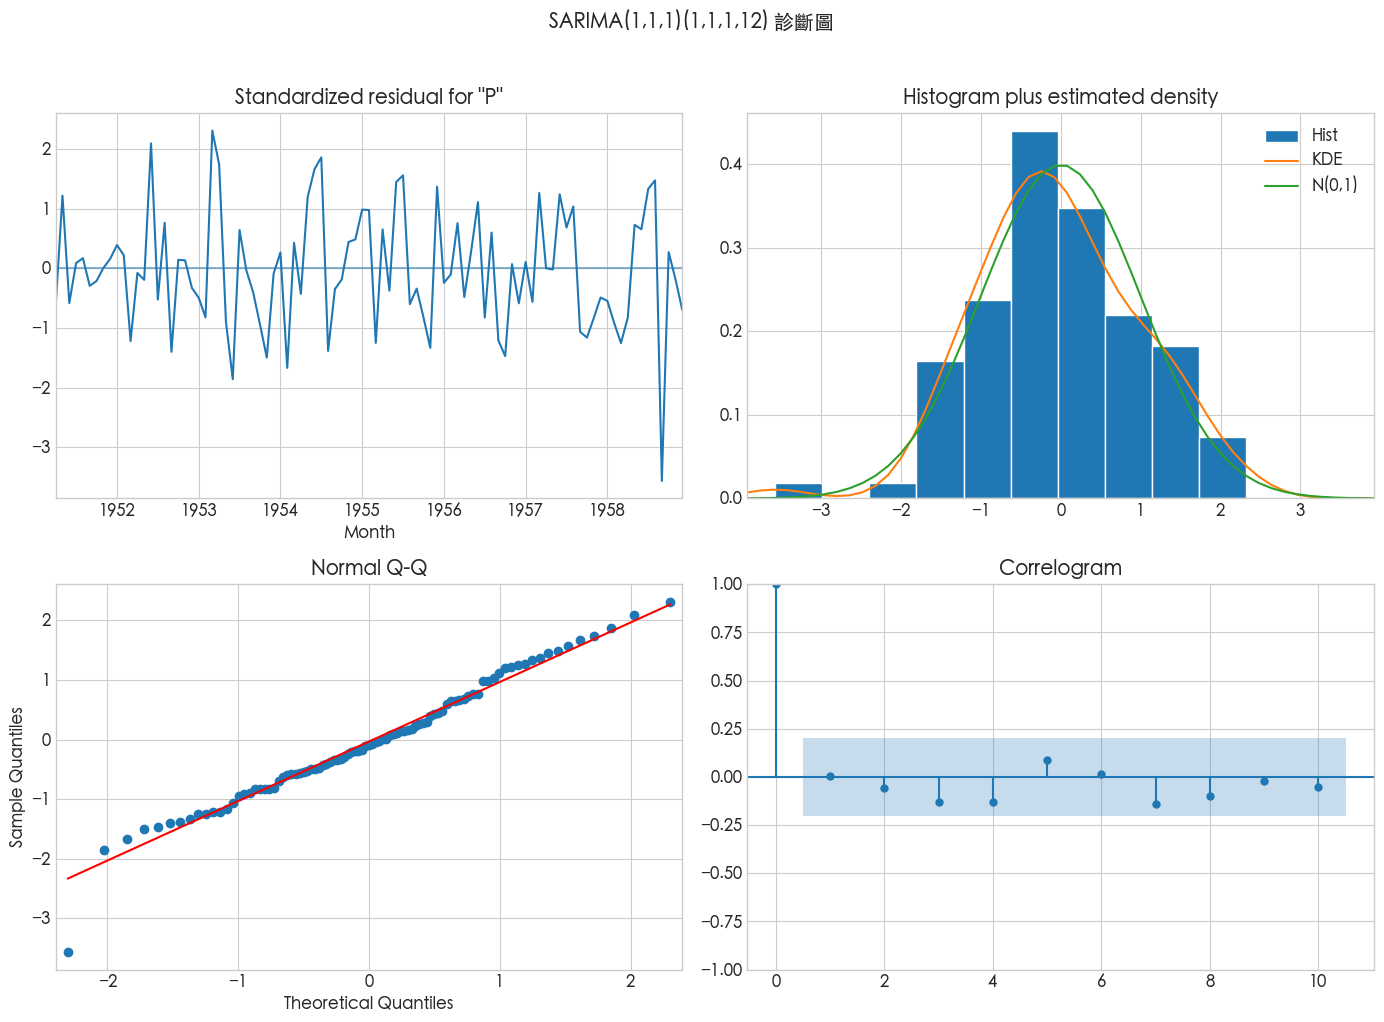

In [33]:
# SARIMA 診斷
fig = sarima_model.plot_diagnostics(figsize=(14, 10))
plt.suptitle('SARIMA(1,1,1)(1,1,1,12) 診斷圖', y=1.02)
plt.tight_layout()
plt.show()

## 2.9 模型比較與最終預測

In [ ]:
# 彙整所有指標
all_metrics = [ma_metrics, hw_metrics, arima_metrics, sarima_metrics]
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('模型')

print("模型比較：")
print("=" * 70)
print(comparison_df.round(2).to_string())
print("\n最佳模型：SARIMA（MAPE 最低）")

In [ ]:
# 視覺化所有預測結果比較
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 完整檢視
axes[0].plot(train, label='訓練集', color='blue', alpha=0.7)
axes[0].plot(test, label='測試集（實際值）', color='black', linewidth=2)
axes[0].plot(ma_forecast, label='移動平均', linestyle='--', alpha=0.7)
axes[0].plot(hw_forecast, label='Holt-Winters', linestyle='--', alpha=0.7)
axes[0].plot(arima_forecast, label='ARIMA', linestyle='--', alpha=0.7)
axes[0].plot(sarima_forecast, label='SARIMA', linestyle='--', alpha=0.7)
axes[0].set_title('所有模型比較')
axes[0].set_xlabel('日期')
axes[0].set_ylabel('乘客人數')
axes[0].legend(loc='upper left')

# 測試期間放大檢視
axes[1].plot(test, label='實際值', color='black', linewidth=2, marker='o', markersize=4)
axes[1].plot(ma_forecast, label=f'MA (MAPE={ma_metrics["MAPE (%)"]:.1f}%)', linestyle='--', marker='s', markersize=3)
axes[1].plot(hw_forecast, label=f'HW (MAPE={hw_metrics["MAPE (%)"]:.1f}%)', linestyle='--', marker='^', markersize=3)
axes[1].plot(arima_forecast, label=f'ARIMA (MAPE={arima_metrics["MAPE (%)"]:.1f}%)', linestyle='--', marker='d', markersize=3)
axes[1].plot(sarima_forecast, label=f'SARIMA (MAPE={sarima_metrics["MAPE (%)"]:.1f}%)', linestyle='--', marker='v', markersize=3)
axes[1].set_title('測試期間（放大）')
axes[1].set_xlabel('日期')
axes[1].set_ylabel('乘客人數')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# 評估指標長條圖比較
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = comparison_df.index.tolist()
x_pos = np.arange(len(models))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# RMSE
axes[0].bar(x_pos, comparison_df['RMSE'], color=colors, alpha=0.8)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE 比較（越低越好）')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=20, ha='right')

# MAE
axes[1].bar(x_pos, comparison_df['MAE'], color=colors, alpha=0.8)
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE 比較（越低越好）')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=20, ha='right')

# MAPE
axes[2].bar(x_pos, comparison_df['MAPE (%)'], color=colors, alpha=0.8)
axes[2].set_ylabel('MAPE (%)')
axes[2].set_title('MAPE 比較（越低越好）')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models, rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# 使用最佳模型（SARIMA）進行未來預測
# 在完整資料上重新擬合
final_model = SARIMAX(
    passengers,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# 預測未來 24 個月
future_forecast = final_model.get_forecast(steps=24)
forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int(alpha=0.05)

# 繪圖
plt.figure(figsize=(14, 6))
plt.plot(passengers, label='歷史資料', color='blue')
plt.plot(forecast_mean, label='預測', color='red', linewidth=2)
plt.fill_between(forecast_ci.index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 color='red', alpha=0.2, label='95% 信賴區間')
plt.title('航空乘客預測（未來 24 個月）')
plt.xlabel('日期')
plt.ylabel('乘客人數（千人）')
plt.legend()
plt.show()

print("\n預測摘要（未來 24 個月）：")
print("-" * 40)
print(f"預測起始：{forecast_mean.index.min()}")
print(f"預測結束：{forecast_mean.index.max()}")
print(f"最小預測值：{forecast_mean.min():.1f}")
print(f"最大預測值：{forecast_mean.max():.1f}")

---
# 第三部分：面試問答
---

透過這些常見面試問題測試你的理解程度。點擊展開答案。

### Q1：什麼是定態性？為什麼它對時間序列建模很重要？

<details>
<summary>點擊展開答案</summary>

**定態性（Stationarity）** 表示時間序列的統計性質（平均數、變異數、自相關）隨時間保持恆定。

**為什麼重要：**
- 大多數時間序列模型（ARIMA、ARMA）假設定態性
- 非定態資料可能導致虛假關係和不可靠的預測
- 只有對定態資料，模型參數才有意義且穩定

**類型：**
- **嚴格定態**：所有動差都不隨時間變化（實務上很少見）
- **弱定態**：平均數、變異數和自共變異數不隨時間變化（我們通常檢驗的）

**如何檢驗：**
- 視覺檢驗（滾動平均/標準差）
- 擴增 Dickey-Fuller（ADF）檢定
- KPSS 檢定
</details>

### Q2：ARIMA(p, d, q) 中的 p、d、q 分別代表什麼？

<details>
<summary>點擊展開答案</summary>

| 參數 | 名稱 | 意義 | 如何選擇 |
|-----------|------|---------|---------------|
| **p** | AR 階數 | 自迴歸落後期數（Y 的過去值） | PACF 在落後 p 期後截斷 |
| **d** | 差分 | 對資料進行差分的次數 | 直到序列定態（ADF 檢定） |
| **q** | MA 階數 | 移動平均落後期數（過去誤差） | ACF 在落後 q 期後截斷 |

**範例：ARIMA(2, 1, 1)**
- p=2：使用最近 2 個值（$Y_{t-1}$, $Y_{t-2}$）
- d=1：差分一次使其定態
- q=1：使用最近 1 個誤差項（$\epsilon_{t-1}$）

**數學形式：**
$$Y'_t = c + \phi_1 Y'_{t-1} + \phi_2 Y'_{t-2} + \theta_1 \epsilon_{t-1} + \epsilon_t$$
其中 $Y'_t = Y_t - Y_{t-1}$（差分後）
</details>

### Q3：如何使用 ACF 和 PACF 選擇 ARIMA 參數？

<details>
<summary>點擊展開答案</summary>

**逐步方法：**

1. **先檢查定態性**。若非定態，對資料進行差分（決定 d）

2. **觀察定態序列的 ACF 和 PACF**：

| 模式 | ACF | PACF | 模型 |
|---------|-----|------|-------|
| AR(p) | 拖尾（指數/正弦衰減） | 在落後 p 期後截斷 | 用 PACF 找 p |
| MA(q) | 在落後 q 期後截斷 | 拖尾 | 用 ACF 找 q |
| ARMA(p,q) | 拖尾 | 拖尾 | 嘗試不同組合 |

3. **「截斷」** = 急遽下降至接近零並保持在信賴區間內

4. **「拖尾」** = 逐漸衰減趨近零

**替代方法：使用 AIC/BIC** 比較不同參數組合，選擇資訊準則最低的模型。
</details>

### Q4：ACF 和 PACF 有什麼區別？

<details>
<summary>點擊展開答案</summary>

**ACF（自相關函數）：**
- 測量 $Y_t$ 和 $Y_{t-k}$ 之間的相關性
- 包含透過中間落後期的**直接和間接**影響
- 範例：ACF(3) 包含落後 1 和 2 期的影響

**PACF（偏自相關函數）：**
- 測量 $Y_t$ 和 $Y_{t-k}$ 在**移除**中間落後期影響後的相關性
- 僅顯示每個落後期的**直接**關係
- 範例：PACF(3) 僅顯示落後 3 期的相關性，控制了落後 1 和 2 期

**類比：**
- ACF：包含所有路徑的總相關
- PACF：僅直接相關，類似偏迴歸係數

**用途：**
- ACF → 識別 MA 階數（q）
- PACF → 識別 AR 階數（p）
</details>

### Q5：時間序列交叉驗證與一般交叉驗證有何不同？

<details>
<summary>點擊展開答案</summary>

**一般 k 折交叉驗證：**
- 隨機將資料分成 k 折
- 任何觀測值都可能在訓練或測試集中
- 假設觀測值獨立

**時間序列交叉驗證（滾動預測驗證）：**
- **尊重時間順序** - 訓練永遠在測試之前
- 永遠不用未來資料預測過去
- 使用擴展或滑動視窗方法

**範例（擴展視窗）：**
```
折 1：訓練 [1-10]，測試 [11-12]
折 2：訓練 [1-12]，測試 [13-14]
折 3：訓練 [1-14]，測試 [15-16]
...
```

**為什麼重要：**
- 時間序列具有時間相依性
- 隨機打亂會洩漏未來資訊（資料洩漏）
- 更真實地模擬實際預測情境

**在 sklearn 中：** 使用 `TimeSeriesSplit` 而非 `KFold`
</details>

### Q6：如何處理時間序列中的季節性？

<details>
<summary>點擊展開答案</summary>

**1. 分解：**
- 加法：$Y_t = T_t + S_t + R_t$（恆定的季節振幅）
- 乘法：$Y_t = T_t \times S_t \times R_t$（季節振幅隨水準增長）

**2. 季節差分：**
- $Y'_t = Y_t - Y_{t-s}$，其中 s 是季節週期
- 範例：月資料具有年度季節性，s=12

**3. SARIMA：**
- 擴展 ARIMA 加入季節項：(P, D, Q, s)
- 同時建模季節和非季節模式

**4. 傅立葉項：**
- 加入正弦和餘弦項作為特徵
- 適用於機器學習模型

**5. 季節虛擬變數：**
- 對月份/季度進行獨熱編碼
- 適用於任何迴歸模型

**如何識別季節性：**
- 按週期（月、季）的盒鬚圖
- ACF 在季節落後期顯示顯著尖峰
- 季節分解
</details>

### Q7：加法分解和乘法分解有什麼區別？

<details>
<summary>點擊展開答案</summary>

**加法分解：**
$$Y_t = T_t + S_t + R_t$$

- 季節變異**恆定**，不受水準影響
- 範例：每年 12 月銷售增加 1000 元（相同的絕對數量）
- 使用時機：季節波動不隨平均值改變

**乘法分解：**
$$Y_t = T_t \times S_t \times R_t$$

- 季節變異**隨水準縮放**
- 範例：每年 12 月銷售增加 20%（比例）
- 使用時機：季節振幅隨序列增長而增大

**如何選擇：**
- 繪製資料：如果季節波動隨時間增長 → 乘法
- 對數轉換可將乘法轉為加法：
  $\log(Y_t) = \log(T_t) + \log(S_t) + \log(R_t)$
- 檢查殘差變異數：正確模型應使變異數更恆定
</details>

### Q8：評估時間序列預測使用哪些指標？

<details>
<summary>點擊展開答案</summary>

| 指標 | 公式 | 解讀 |
|--------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum|y_t - \hat{y}_t|$ | 平均絕對誤差，與資料同單位 |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_t - \hat{y}_t)^2}$ | 對大誤差懲罰更重 |
| **MAPE** | $\frac{100}{n}\sum|\frac{y_t - \hat{y}_t}{y_t}|$ | 百分比誤差，與尺度無關 |
| **sMAPE** | $\frac{200}{n}\sum\frac{|y_t - \hat{y}_t|}{|y_t| + |\hat{y}_t|}$ | 對稱 MAPE，更好處理零值 |

**選擇指標：**
- **MAE**：對離群值穩健，易於解讀
- **RMSE**：可微分，懲罰大誤差
- **MAPE**：適合跨不同尺度比較
  - 注意：當實際值為 0 時無定義
  - 不對稱：對高估的懲罰較輕

**最佳實務：** 報告多個指標以獲得完整圖像。
</details>

### Q9：過擬合在時間序列模型中如何表現？

<details>
<summary>點擊展開答案</summary>

**過擬合的跡象：**
1. **訓練與測試差距**：樣本內誤差低，樣本外誤差高
2. **參數過多**：相對於資料量，p 和 q 值過高
3. **擬合過於完美**：訓練資料上的殘差不切實際地低

**原因：**
- 包含過多 AR/MA 項
- 擬合雜訊而非訊號
- 訓練期間短卻使用複雜模型

**預防策略：**
1. **使用資訊準則**（AIC、BIC）懲罰複雜度
2. **時間序列交叉驗證** 進行樣本外驗證
3. **簡約原則**：從簡單開始，僅在需要時增加複雜度
4. **檢查殘差**：應為白噪音（無剩餘模式）

**經驗法則：** 總參數（p + q + P + Q）應遠小於樣本量。
</details>

### Q10：解釋擴增 Dickey-Fuller（ADF）檢定。

<details>
<summary>點擊展開答案</summary>

**目的：** 檢驗定態性（具體來說，單位根）

**假設：**
- $H_0$：序列具有單位根（非定態）
- $H_1$：序列為定態

**檢定方程式：**
$$\Delta Y_t = \alpha + \beta t + \gamma Y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta Y_{t-i} + \epsilon_t$$

- 檢驗 $\gamma = 0$（存在單位根）
- 透過落後差分項處理自相關

**解讀：**
- **p 值 < 0.05**：拒絕 $H_0$ → 序列為定態
- **p 值 ≥ 0.05**：無法拒絕 $H_0$ → 序列為非定態

**實務上：**
```python
from statsmodels.tsa.stattools import adfuller
result = adfuller(series)
print(f'ADF 統計量：{result[0]}')
print(f'p 值：{result[1]}')
```
</details>

### Q11：什麼是指數平滑法？何時使用它？

<details>
<summary>點擊展開答案</summary>

**概念：** 對近期觀測值賦予較高權重，權重呈指數衰減。

**類型：**

| 模型 | 成分 | 使用情境 |
|-------|------------|----------|
| 簡單指數平滑 | 僅水準 | 無趨勢、無季節性 |
| Holt 法 | 水準 + 趨勢 | 有趨勢、無季節性 |
| Holt-Winters 法 | 水準 + 趨勢 + 季節性 | 有趨勢和季節性 |

**簡單指數平滑：**
$$\hat{Y}_{t+1} = \alpha Y_t + (1-\alpha) \hat{Y}_t$$
- $\alpha$：平滑參數（0 < α < 1）
- α 越高 → 越重視近期資料

**何時使用：**
- 快速、可解讀的預測
- 短期預測
- 計算效率重要時
- 在嘗試複雜模型前作為基準

**相較於 ARIMA 的優勢：**
- 更簡單，參數更少
- 不需要定態性假設
- 實務上往往效果不錯
</details>

### Q12：AR 和 MA 過程有什麼區別？

<details>
<summary>點擊展開答案</summary>

**AR（自迴歸）過程：**
$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + ... + \epsilon_t$$

- 當前值取決於序列的**過去值**
- 透過觀測值傳遞記憶
- PACF 截斷，ACF 拖尾

**MA（移動平均）過程：**
$$Y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + ...$$

- 當前值取決於**過去誤差**（衝擊）
- 透過誤差項傳遞記憶
- ACF 截斷，PACF 拖尾

**比較：**

| 面向 | AR | MA |
|--------|----|----|  
| 記憶 | 透過過去值 | 透過過去衝擊 |
| 脈衝響應 | 無限 | 有限（q 期） |
| ACF 模式 | 逐漸衰減 | 在落後 q 期後截斷 |
| PACF 模式 | 在落後 p 期後截斷 | 逐漸衰減 |

**直覺理解：**
- AR：「上個月經濟好，所以這個月可能也好」
- MA：「2 個月前的衝擊還在影響我們」
</details>

### Q13：如何處理時間序列中的遺漏值？

<details>
<summary>點擊展開答案</summary>

**方法：**

1. **前向填補（最後觀測值向前）：**
   - 用前一個值填補遺漏
   - `df.fillna(method='ffill')`
   - 適用於：緩慢變化的序列

2. **後向填補：**
   - 用下一個值填補遺漏
   - `df.fillna(method='bfill')`
   
3. **線性內插：**
   - 在相鄰值之間線性估計遺漏值
   - `df.interpolate(method='linear')`
   - 適用於：有趨勢的資料

4. **季節內插：**
   - 使用前一週期相同時點的值
   - 適用於：強季節性資料

5. **基於模型的填補：**
   - 使用 ARIMA 或其他模型預測遺漏值
   - 最精密但可能引入偏誤

**最佳實務：**
- 了解資料遺漏的原因（MCAR、MAR、MNAR）
- 記錄填補方法
- 考慮使用不同方法進行敏感度分析
- 若遺漏值過多則不要填補
</details>

### Q14：SARIMA 中的季節參數（P, D, Q, s）是什麼？

<details>
<summary>點擊展開答案</summary>

**SARIMA(p, d, q)(P, D, Q, s)：**

| 參數 | 意義 | 範例（月資料，s=12） |
|-----------|---------|-----------------------------|
| **P** | 季節 AR 階數 | 落後 12、24... 期 |
| **D** | 季節差分 | $Y_t - Y_{t-12}$ |
| **Q** | 季節 MA 階數 | 落後 12、24... 期的誤差 |
| **s** | 季節週期 | 月資料為 12，季資料為 4 |

**範例：SARIMA(1,1,1)(1,1,1,12)**
- 非季節：AR(1)，差分一次，MA(1)
- 季節：落後 12 期的 SAR(1)，季節差分，落後 12 期的 SMA(1)

**如何識別：**
- 觀察季節落後期（12、24、36...）的 ACF/PACF
- 若 ACF 在落後 12 期有顯著尖峰 → 考慮加入季節成分
- 季節差分（D=1）通常足以處理大多數資料

**常見選擇：**
- 月資料：s=12
- 季資料：s=4
- 週資料（每日觀測）：s=7
</details>

### Q15：何時使用 ARIMA vs 機器學習進行時間序列？

<details>
<summary>點擊展開答案</summary>

**使用 ARIMA 的情境：**
- 單變量時間序列（單一變數）
- 專注於時間模式（趨勢、季節性）
- 需要可解釋的模型
- 資料量有限
- 需要統計推論（信賴區間）

**使用 ML（Random Forest、XGBoost、LSTM）的情境：**
- 有多個特徵/變數
- 複雜的非線性關係
- 大型資料集
- 外部預測變數重要（天氣、假日）
- 優先考慮準確度而非可解釋性

**混合方法：**
- 用 ARIMA 作為基準，用 ML 嘗試超越
- 特徵工程時間成分（落後特徵、滾動統計）
- 集成：結合 ARIMA 和 ML 的預測

**常見的 ML 時間序列特徵：**
- 落後值：$Y_{t-1}, Y_{t-2}, ...$
- 滾動統計：移動平均、標準差
- 時間特徵：月份、星期幾、假日
- 外部特徵：天氣、經濟指標
</details>

---
## 總結

在本筆記本中，我們涵蓋了：

1. **時間序列基礎**：定義、組成成分（趨勢、季節性、殘差）及定態性
2. **ACF/PACF 分析**：如何解讀自相關圖並選擇 ARIMA 參數
3. **實務實作**：從資料載入到預測的完整流程
4. **模型比較**：簡單方法 vs ARIMA vs SARIMA
5. **面試準備**：15 個常見問題與詳細解答

### 重點回顧

- 在擬合 ARIMA 模型前務必檢查定態性
- 使用 ACF/PACF 引導參數選擇
- SARIMA 能處理季節性；對季節性資料使用它
- 時間序列交叉驗證必須尊重時間順序
- 報告多個評估指標（RMSE、MAE、MAPE）
- 在嘗試複雜模型前先用簡單方法（指數平滑）作為基準